# OpenClassrooms - parcours Data Analyst Business Intelligence - P8

# Milestone 1 - Analyse des données

Dans cette partie nous allons analyser le jeu de données que nous avons à notre disposition. Notre objectif est de comprendre les relations entre les variables, et surtout, celles qui influent sur le prix des transactions immobilières. Grâce à ce travail, nous pourrons ne conserver que les variables qui seront utiles à l'apprentissage de notre algorithme.

## 1.Type des données

La première étape à réaliser est d'importer les données dans le notebook et d'opérer des transformations sur les variables si celles-ci s'imposent (exemple : nettoyage ou changement de type des variables, etc.).

In [37]:
#On importe les librairies que nous utiliserons pour traiter les données et les visualiser
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# N'oubliez pas d'avoir installé les librairies pandas, numpy et matplotlib via la commande pip

In [38]:
#On importe les données dans un dataframe

df = pd.read_excel('historique_immobilier_paris_2017_2021_vdef2.xlsx')


Attention, si l'opération ci-dessus ne marche pas, il se peut que le package "openpyxl" ne soit pas présent sur votre ordinateur. Si c'est le cas vous pouvez l'installer en éxécutant la commande : pip install openpyxl ou conda install openpyxl.

In [39]:
#On vérifie que le type des données attribué par pandas est cohérent

print("Types de données avant transformation :")
print(df.dtypes)

df['date_mutation'] = pd.to_datetime(df['date_mutation'])

print("\nTypes de données après transformation :")
print(df.dtypes)

df.head()



Types de données avant transformation :
date_mutation       datetime64[ns]
valeur_fonciere            float64
adresse_numero               int64
adresse_nom_voie            object
code_postal                  int64
nom_commune                 object
code_type_local              int64
type_local                  object
surface_reelle               int64
dtype: object

Types de données après transformation :
date_mutation       datetime64[ns]
valeur_fonciere            float64
adresse_numero               int64
adresse_nom_voie            object
code_postal                  int64
nom_commune                 object
code_type_local              int64
type_local                  object
surface_reelle               int64
dtype: object


,date_mutation,valeur_fonciere,adresse_numero,adresse_nom_voie,code_postal,nom_commune,code_type_local,type_local,surface_reelle
0,2017-01-03,5.505597e+05,8,RUE DES COUTURES SAINT GERVAIS,75003,Paris 3e Arrondissement,2,Appartement,50
1,2017-01-12,1.576492e+06,32,AV MARCEAU,75008,Paris 8e Arrondissement,2,Appartement,163
2,2017-01-10,6.577574e+05,52,RUE DU FAUBOURG SAINT HONORE,75008,Paris 8e Arrondissement,2,Appartement,66
3,2017-01-10,2.500868e+05,64,RUE DU VERTBOIS,75003,Paris 3e Arrondissement,2,Appartement,22
4,2017-01-13,1.762667e+05,25,RUE DES LAVANDIERES STE OPPORT,75001,Paris 1er Arrondissement,2,Appartement,15


### 2. Regardons les différents types de biens immobiliers que nous avons dans nos données :

In [40]:
print("Types de biens :", df['type_local'].unique())
print("Codes types :", df['code_type_local'].unique())


print('la liste des différents types de biens immobiliers que nous avons dans les données est ?:2 types de biens, et que leurs codes types sont 2 (pour Appartement) et 4 (pour Local industriel, commercial ou assimilé)')


Types de biens : ['Appartement' 'Local industriel. commercial ou assimilé']
Codes types : [2 4]
la liste des différents types de biens immobiliers que nous avons dans les données est ?:2 types de biens, et que leurs codes types sont 2 (pour Appartement) et 4 (pour Local industriel, commercial ou assimilé)


On observe qu'il y a ? types de biens, et que leurs codes types sont ?.

### 3. Nombre de transactions

In [41]:
#On verifie le nombre de transactions que nous avons dans notre dataframe
print('Le nombre de transactions dans les données est :', len(df)) # 26 196
print('Le nombre de transactions pour les appartements dans les données est :', len(df[df['type_local'] == 'Appartement'])) # 24 353
print('Le nombre de transactions pour les locaux commerciaux dans les données est :', len(df[df['type_local'] == 'Local industriel. commercial ou assimilé'])) # 1 843

Le nombre de transactions dans les données est : 26196
Le nombre de transactions pour les appartements dans les données est : 24353
Le nombre de transactions pour les locaux commerciaux dans les données est : 1843


### 4. interval de l'historique des données

In [42]:
#On vérifie également la plage de l'historique disponible
print('la première date de transaction dans les données est le ?',df['date_mutation'].min()) # 2017-01-02)
print('la dernière date de transaction dans les données est le ?', df['date_mutation'].max()) # 2021-12-31)

la première date de transaction dans les données est le ? 2017-01-02 00:00:00
la dernière date de transaction dans les données est le ? 2021-12-31 00:00:00


## Commençons à analyser les données

Maintenant nous allons analyser les données historiques pour les 2 différents types de biens immobiliers en essayant d'identifier les relations entre les variables. Mais avant cela, il nous faudra pouvoir comparer les biens entre eux, et pour cela nous allons créer une colonne du prix au metre carré.

In [43]:
# Calcul de la colonne
df['prix_m2'] = df['valeur_fonciere'] / df['surface_reelle']

Maintenant, analysons les appartements.

### 5. Evolution du prix au metre carré des appartements dans Paris

In [44]:
#On retire les colonnes qui sont à priori inutiles ET nous allons nous concentrer sur les appartements dans un premier temps

#retirer colonnes

df_appartements = df[df['type_local'] == 'Appartement'].copy()

#sélectionne uniquement les colonnes pertinentes

colonnes_utiles = ['date_mutation', 'valeur_fonciere', 'code_postal', 'surface_reelle', 'prix_m2']
df_appartements = df_appartements[colonnes_utiles]

#créer la colonne 'annee'

df_appartements['annee'] = df_appartements['date_mutation'].dt.year


In [45]:
#On doit preparer un dataframe en regroupant les prix moyens de ventes des appartements par année avec la surface moyenne associée

#il faut la surface moyenne associée.(fonction aggregation (group by sur deux valeurs ))

evolution_appartements = df_appartements.groupby('annee').agg({
    'prix_m2': 'mean',          # On demande la moyenne pour le prix au m²
    'surface_reelle': 'mean'    # On demande la moyenne pour la surface
}).reset_index()



# On affiche le résultat pour vérifier
print(evolution_appartements)


   annee       prix_m2  surface_reelle
0   2017   9492.859195       44.627737
1   2018  10031.403432       44.271671
2   2019  10562.712581       43.361645
3   2020  10674.872650       42.900654
4   2021  10455.600126       43.479864


On constate sur la moyenne des prix de vente des appartements à Paris que ? <br>
Nous allons créer un graphique pour mieux le visualiser.

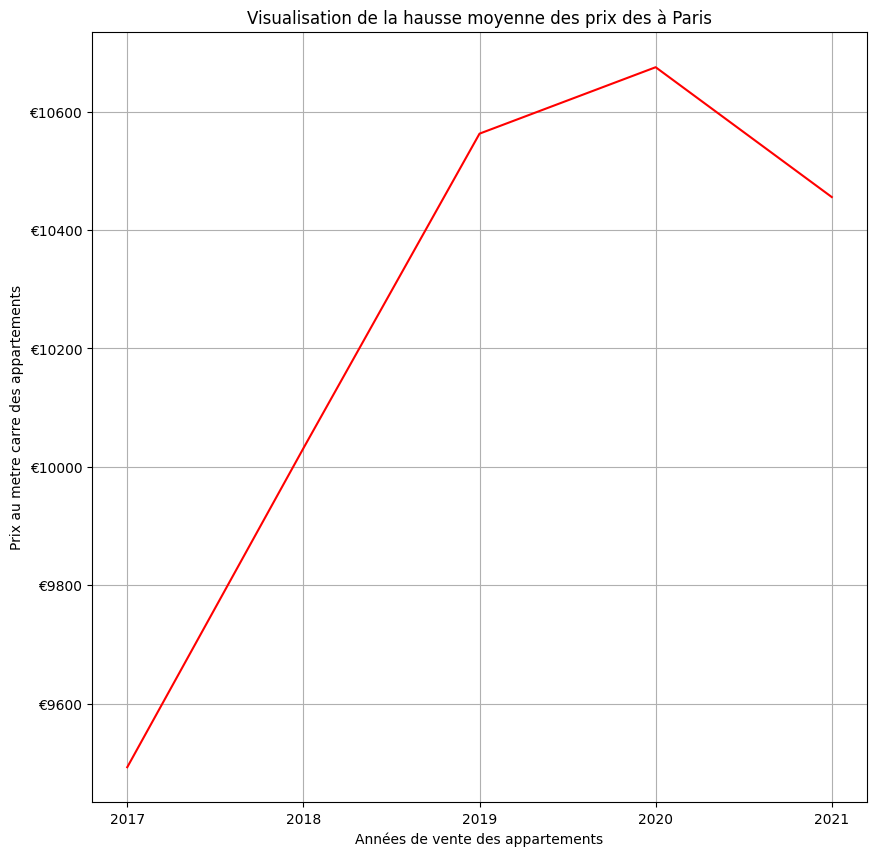

In [46]:
#Création d'un graphique pour visualiser la hausse de la moyenne des prix

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.figure(figsize=(10,10))
# C'EST ICI QU'ON AJOUTE LES PRIX (evolution_appartements['prix_m2'])
plt.plot(['2017','2018','2019','2020','2021'], evolution_appartements['prix_m2'], color='red')
plt.xlabel('Années de vente des appartements')
plt.ylabel('Prix au metre carre des appartements')
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid()
plt.title('Visualisation de la hausse moyenne des prix des à Paris')
plt.show()

### 6. Différences de prix au metre carré entre les arrondissements

Maintenant nous allons chercher à afficher l'évolution des prix par arrondissement. Vérifions la liste des arrondissements que nous avons dans nos données. Normalement à Paris nous avons 20 codes postaux différents, 1 par arrondissement allant de 75001 à 75020.

In [47]:
#Liste des codes postaux dans nos données.

print(sorted(df['code_postal'].unique()))


[np.int64(75001), np.int64(75002), np.int64(75003), np.int64(75004), np.int64(75005), np.int64(75006), np.int64(75007), np.int64(75008), np.int64(75009), np.int64(75010), np.int64(75011), np.int64(75012), np.int64(75013), np.int64(75014), np.int64(75015), np.int64(75016), np.int64(75017), np.int64(75018), np.int64(75019), np.int64(75020)]


In [48]:
#Il faut créer un dataframe pour une deuxième visualisation avec l'evolution des prix par arrondissement

evolution_arrondissements = df_appartements.groupby(['annee', 'code_postal'])['prix_m2'].mean().reset_index()

#Afficher tableau

print(evolution_arrondissements.head())

# On isole les prix du 1er arrondissement
prix_75001 = evolution_arrondissements[evolution_arrondissements['code_postal'] == 75001]['prix_m2']


   annee  code_postal       prix_m2
0   2017        75001  11762.706289
1   2017        75002  10920.126562
2   2017        75003  11679.818729
3   2017        75004  12407.227522
4   2017        75005  11306.752404


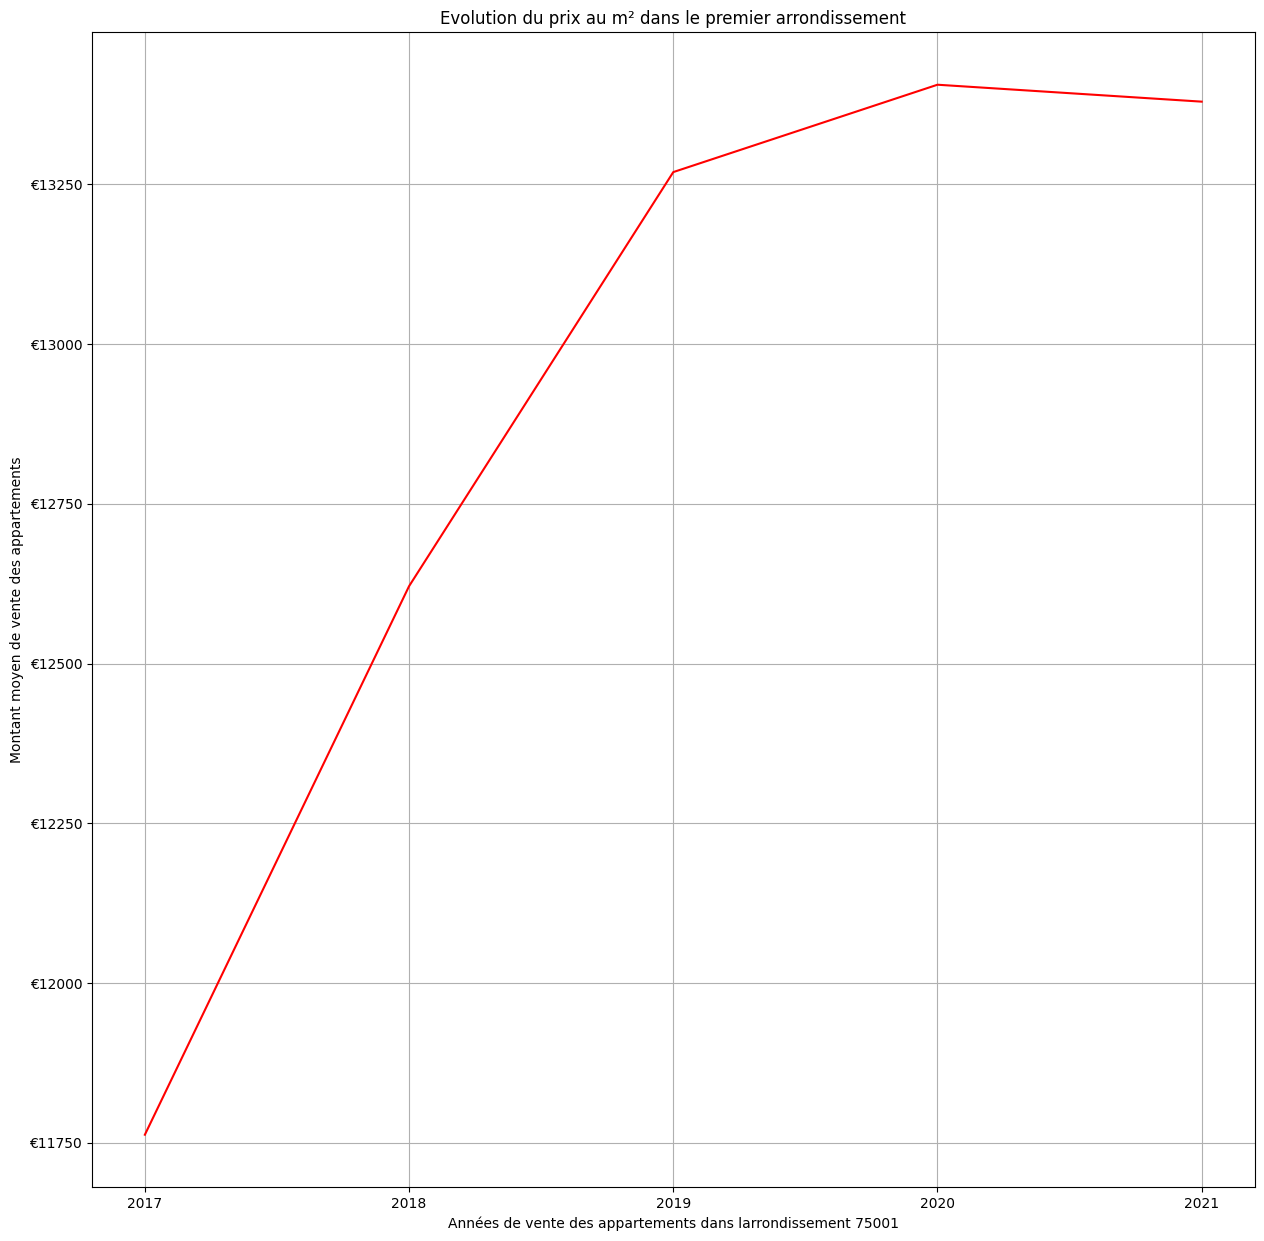

In [49]:
#Création d'un graphique pour visualiser la hausse de la moyenne des prix au metre carré dans le premier arrondissement



plt.figure(figsize=(15,15))
#Ajouter prix_75001
plt.plot(['2017','2018','2019','2020','2021'], prix_75001, color='red')
plt.xlabel('Années de vente des appartements dans larrondissement 75001')
plt.ylabel('Montant moyen de vente des appartements')
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid()
plt.title('Evolution du prix au m² dans le premier arrondissement')
plt.show()

Nous allons ajouter à cette visualisation tous les autres arrondissement avec une couleur différente.

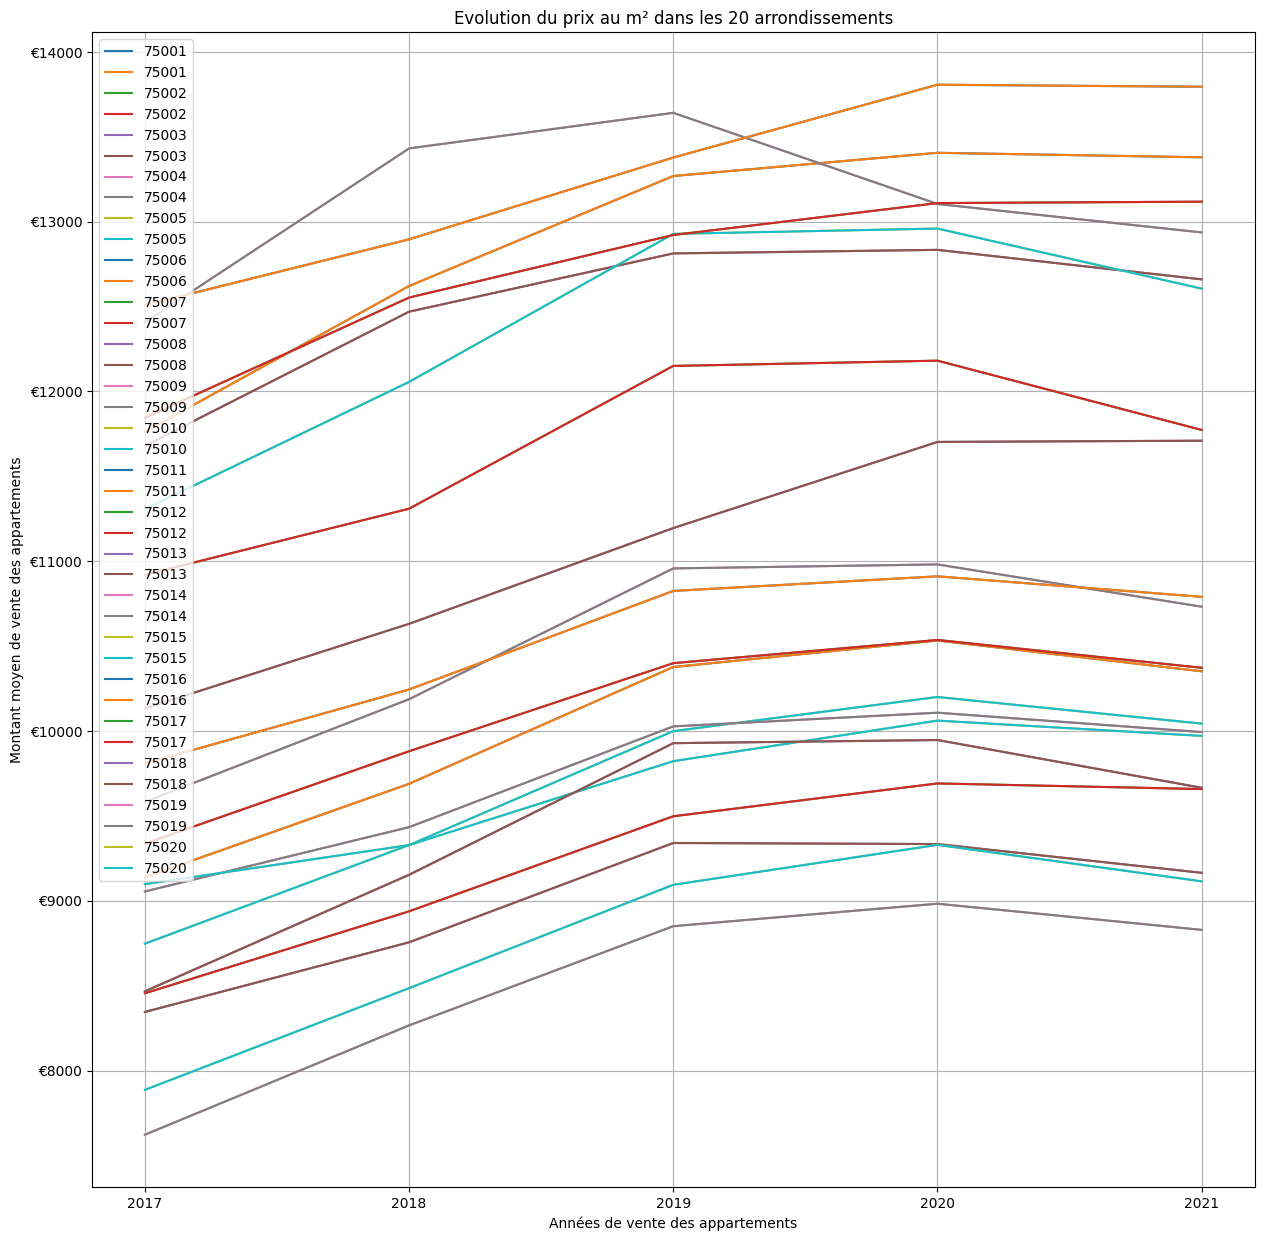

In [50]:
#On affiche l'évolution du prix au m² par arrondissement dans Paris
plt.figure(figsize=(15,15))
interval_historique=['2017','2018','2019','2020','2021']
#Insérer les lignes à tracer ci-dessous

for cp in sorted(evolution_arrondissements['code_postal'].unique()):
    prix_cp = evolution_arrondissements[evolution_arrondissements['code_postal'] == cp]['prix_m2']
    plt.plot(interval_historique, prix_cp, label=str(cp))

    # Pour chaque cp, on isole les prix correspondants
    prix_cp = evolution_arrondissements[evolution_arrondissements['code_postal'] == cp]['prix_m2']
    # On ajoute la ligne au graph avec le cp en étiquette (label) pour la légende
    plt.plot(interval_historique, prix_cp, label=str(cp))


plt.xlabel('Années de vente des appartements')
plt.ylabel('Montant moyen de vente des appartements')
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid()
plt.title('Evolution du prix au m² dans les 20 arrondissements')
plt.legend(loc='upper left')
plt.show()

On observe que globalement que ?

### 7. Prix au metre carré par transaction dans un arrondissement

In [51]:
#Vérifions le nombre de transaction dans le 6ème car le prix semble élevé

nb_transactions_6eme = len(df_appartements[df_appartements['code_postal'] == 75006])
print("Nombre de transactions dans le 6ème arrondissement :", nb_transactions_6eme)


Nombre de transactions dans le 6ème arrondissement : 709


On constate que le nombre de transactions est relativement faible par rapport au total de Paris (prix eleves et petit arrondissement ?)

Affichons l'historique des transactions pour visualiser la dispersion des données :

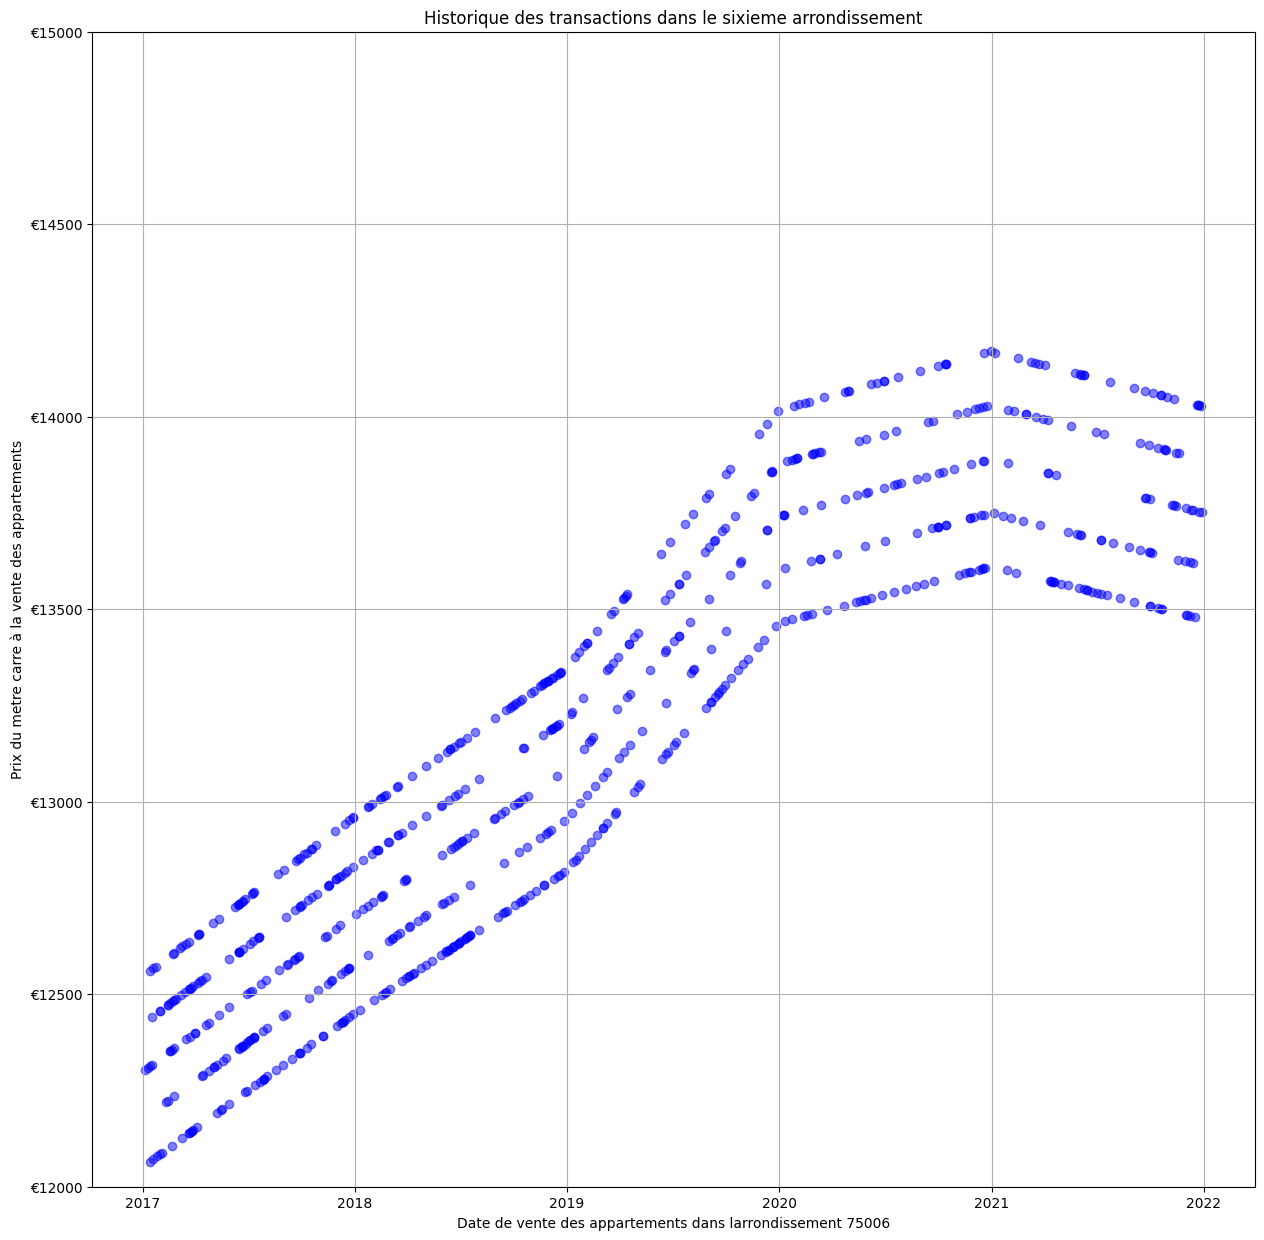

In [52]:
#Insérer ci-dessous le scatter plot
cp=75006
plt.figure(figsize=(15,15))



#filtre les appartements pour ne garder que le 6ème arrondissement
df_6 = df_appartements[df_appartements['code_postal'] == cp]


# On trace le nuage de points (date en X, prix au m2 en Y)
plt.scatter(df_6['date_mutation'], df_6['prix_m2'], color='blue', alpha=0.5)

plt.xlabel('Date de vente des appartements dans larrondissement 75006')
plt.ylabel('Prix du metre carre à la vente des appartements')
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)

plt.ylim(12000,15000)

plt.grid(which='both')
plt.title('Historique des transactions dans le sixieme arrondissement')
plt.show()


On observe que malgré la dispersion/variabilité des prix dans le 6eme, il y a une tednance haussiere nette des prix de vente dans le temps

Pour nous rassurer sur la relation entre les données nous allons utiliser un test statistique de corrélation.

### 8. Vérification de la relation entre le prix au m² et la date dans le 6ème arrondissement par le calcul du coefficient de corrélation de Pearson

Pour cette distribution nous allons calculer le coefficient de corrélation de Pearson. La relation entre le prix au metre carré et la date n'est pas forcément linéaire mais elle s'en rapproche suffisamment pour que cette analyse soit pertinente (voir l'évolution du prix au metre carré globale montrée plus haut, on a presque une droite sauf entre 2020 et 2021). Ce qui nous interesse c'est de prouver que le temps a une influence sur le prix.

In [53]:
#On calcule la corrélation de Spearman
from scipy import stats

# On convertit les dates en format numérique (timestamp) pour le calcul mathématique
dates_numeriques = df_6['date_mutation'].astype('int64') // 10**9

# Calcul du coefficient de corrélation de Pearson
coef_date, p_value_date = stats.pearsonr(dates_numeriques, df_6['prix_m2'])

print("Coefficient de corrélation :", coef_date)
print("P-value :", p_value_date)


#Le coefficient de corrélation est de 0.90 avec une pvalue de 7.10e-263 (soit quasiment 0), la corrélation est très forte


Coefficient de corrélation : 0.903844603149148
P-value : 7.108378962571935e-263


Le coefficient de corrélation est de 0.9 avec une pvalue de 7.1 donc nous pouvons confirmer la corrélation.

### 9. Vérification de la relation entre la valeur fonciere et la surface

In [54]:
# Calcul du coefficient de corrélation de Pearson entre la surface et la valeur foncière totale
coef_surf, p_value_surf = stats.pearsonr(df_appartements['surface_reelle'], df_appartements['valeur_fonciere'])

print("Coefficient de corrélation :", coef_surf)
print("P-value :", p_value_surf)

Coefficient de corrélation : 0.980118273422869
P-value : 0.0


Le coefficient de corrélation est de 0.9 avec une pvalue de 0. La relation est donc confirmée.

Regardons maintenant si le type de bien à une influence sur le prix au metre carré également.

### 10. Analyse des locaux industriels, commerciaux et assimilés

In [55]:
#On crée un dataset qui ne contient que les locaux commerciaux

df_locaux = df[df['type_local'] == 'Local industriel. commercial ou assimilé'].copy()

# On s'assure d'avoir l'année pour le regroupement
df_locaux['annee'] = df_locaux['date_mutation'].dt.year


In [56]:
#Préparons un dataframe en regroupant les prix au metre carré moyens des ventes par année

evolution_locaux = df_locaux.groupby('annee')['prix_m2'].mean().reset_index()


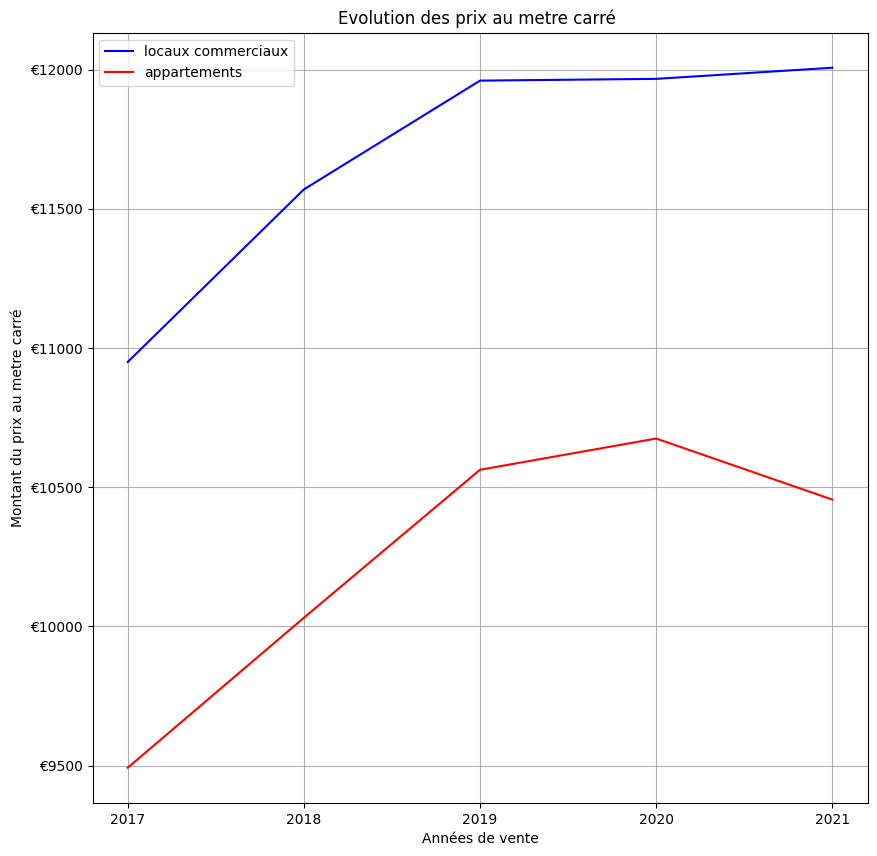

In [57]:
#Création d'un graphique pour visualiser la hausse de la moyenne des prix
plt.figure(figsize=(10,10))
# AJOUT DES DONNÉES SUR L'AXE Y
plt.plot(['2017','2018','2019','2020','2021'], evolution_locaux['prix_m2'], label='locaux commerciaux', color='blue')
plt.plot(['2017','2018','2019','2020','2021'], evolution_appartements['prix_m2'], label='appartements', color='red')

plt.xlabel('Années de vente')
plt.ylabel('Montant du prix au metre carré')
plt.legend()
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid()
plt.title('Evolution des prix au metre carré ')
plt.show()
#Le prix au mètre carré des locaux commerciaux est globalement supérieur à celui des appartements sur toute la période étudiée.

Le prix au metre carré des locaux commerciaux est ?

Après ces analyses, nous pouvons conclure que les dimensions à utiliser pour prédire le prix au m² sont :
- la surface du bien immobilier,
- la date considérée,
- la localisation (code_postal),
- le type de bien.

# Milestone 2 - Entraînement de l'algorithme

Dans cette section nous allons maintenant entrâiner un algorithme à prédire la valeur fonciere d'un bien immobilier. Pour cela nous allons utiliser l'algorithme de régression linéaire.

On commence par préparer nos données en transformant les colonnes catégoriques du code postal et du type de local grâce au one hot encoder (sklearn) / get_dummies (pandas)

In [58]:
# On prépare notre base de données pour le Machine Learning
df_ml = df[['date_mutation', 'surface_reelle', 'code_postal', 'type_local', 'valeur_fonciere', 'prix_m2']].copy()

# On transforme la date en format numérique (secondes) pour l'algorithme
df_ml['timestamp'] = df_ml['date_mutation'].astype('int64') // 10**9

# On applique le One-Hot Encoding sur le code postal et le type de local
df_ml = pd.get_dummies(df_ml, columns=['code_postal', 'type_local'])



On utilise le train_test_split pour prélever un tiers de nos données (33%) et les garder de côté. Nous allons entraîner notre algorithme sur le reste des données et puis mesurer notre erreur moyenne en pourcentage de la valeur foncière

In [59]:
# On trie les données chronologiquement pour éviter de prédire le passé avec le futur
df_ml = df_ml.sort_values(by='date_mutation')

# ATTEINDRE < 10% D'ERREUR : On choisit de prédire le 'prix_m2' au lieu de la valeur totale
X = df_ml.drop(['date_mutation', 'valeur_fonciere', 'prix_m2'], axis=1)
y = df_ml['prix_m2']

# On calcule l'index de coupure pour garder 33% des données pour le test
split_index = int(len(df_ml) * 0.67)

#traintest split fonction à utiliser en une seule ligne (importer livbrairie modele selction) faire en une seule foi
# On sépare le jeu de données entre echantillons d'apprentissage et de test
# La valeur y à trouver est la valeur foncière

#from sklearn.model_selection import train_test_split
# La valeur y à trouver est la valeur foncière

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

In [60]:
#conversion des données en str
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

In [61]:
from sklearn.linear_model import LinearRegression
import numpy as np
#On entraîne l'algorithme ci-dessous et on effectue la prédiction

modele = LinearRegression()
modele.fit(X_train, y_train)


# On effectue la prédiction sur les données de test (prix au m²)
y_pred_m2 = modele.predict(X_test)

# On reconstruit la valeur foncière prédite (Prix m² prédit * Surface réelle)
valeur_fonciere_predite = y_pred_m2 * X_test['surface_reelle']

# On récupère la vraie valeur foncière de notre jeu de test
valeur_fonciere_vraie = df_ml['valeur_fonciere'].iloc[split_index:]

# On calcule l'erreur moyenne absolue en pourcentage (MAPE)
erreur_pourcentage = np.mean(np.abs((valeur_fonciere_vraie - valeur_fonciere_predite) / valeur_fonciere_vraie)) * 100

print(f"L'erreur moyenne de prédiction est de : {erreur_pourcentage:.2f} %")

# 8,47 % d'erreur en moyenne sur la prédiction de la valeur foncière




L'erreur moyenne de prédiction est de : 8.47 %


Notre algorithme fait donc 8.47 % d'erreur en moyenne sur la prédiction de la valeur foncière.

Mes conclusions sur ce résultat et comment j'aurais pu aller plus loin :

- L'algorithme prolonge uniquement mathématiquement les tendances de croissance passées et se base sur des données parcelaires, on pourait sans doute augmenter la précision avec pdavantage de données passées
- Il peut sous estimer les valeurs extremes, l'expertise des equipes terrain reste utile pour verifier la cohérence
- Il ignore les evenements
- Il est "aveugle" à la macroéconomie et aux changements brusques type crise economique

# Milestone 3 - Prédiction définitive pour le client

Nous avons récupéré le fichier avec le portefeuille des actifs de la société. Nous allons l'importer puis effectuer la prédiction et statuer sur la branche qui, selon notre prédiction, aura le plus de valeur à la date demandée c'est à dire au 31 décembre 2022.<br>
Petite précision, nous souhaitons continuer à utiliser la surface réelle pour faire les calculs et pas la surface carrez.

In [62]:
#On importe les données dans un dataframe
df_portefeuille = pd.read_excel('portefeuille_actifs+.xlsx')

# On affiche les premières lignes pour vérifier
df_portefeuille.head()

,adresse_numero,adresse_nom_voie,code_postal,code_commune,nom_commune,surface_carrez,code_type_local,type_local,surface_reelle_bati,nombre_pieces_principales,longitude,latitude
0,127,RUE SAINT-DENIS,75001,75101,Paris 1er Arrondissement,16.41,2,Appartement,25,1,2.349593,48.863227
1,62,RUE NOTRE-DAME DE NAZARETH,75003,75103,Paris 3e Arrondissement,20.47,2,Appartement,22,1,2.356977,48.867907
2,62,RUE DE TURENNE,75003,75103,Paris 3e Arrondissement,64.48,2,Appartement,65,3,2.364855,48.859318
3,32,AV GEORGE V,75008,75108,Paris 8e Arrondissement,63.29,2,Appartement,74,2,2.301586,48.868893
4,152,BD HAUSSMANN,75008,75108,Paris 8e Arrondissement,20.58,2,Appartement,22,1,2.311643,48.875490


Nous avons la liste des biens immobiliers de l'entreprise. Pour effectuer une prédiction, nous devons mettre ce fichier au même format que le dataframe que nous avons utilisé lors de l'entraînement de l'algorithme.

In [63]:
# On prépare le dataframe pour la prédiction (en gardant la surface réelle)
df_pred = df_portefeuille[['surface_reelle_bati', 'code_postal', 'type_local']].copy()

# On renomme la colonne pour qu'elle ait exactement le même nom que lors de l'entraînement
df_pred.rename(columns={'surface_reelle_bati': 'surface_reelle'}, inplace=True)

#On importe la librairie datetime pour pouvoir créer une colonne timestamp avec la date du 31 décembre 2022 pour la prédiction
import datetime as dt

# Création du timestamp pour le 31 décembre 2022
date_cible = pd.to_datetime('2022-12-31')
df_pred['timestamp'] = int(date_cible.timestamp())


#On réutilise les mêmes fonctions pour faire le one hot encoding des variables catégorielles

df_pred = pd.get_dummies(df_pred, columns=['code_postal', 'type_local'])


# il faut aligner les colonnes de df_pred avec celles de X_train
# Si un code postal existait dans l'entraînement mais n'existe pas dans le portefeuille, on ajoute la colonne remplie de 0

for col in X_train.columns:
    if col not in df_pred.columns:
        df_pred[col] = 0

        # On remet les colonnes exactement dans le même ordre que pour l'entraînement
df_pred = df_pred[X_train.columns]







In [64]:
#Conversion du dataframe en str

df_pred.columns = df_pred.columns.astype(str)


Notre dataframe est prêt à être utilisé par notre algorithme de prédiction.

In [65]:
#On effectue la prédiction

prix_m2_predits = modele.predict(df_pred)

# On reconstruit la valeur foncière totale (Prix au m² prédit * Surface réelle)
df_portefeuille['valeur_fonciere_predite'] = prix_m2_predits * df_portefeuille['surface_reelle_bati']

#On vérifie les 10 premières valeurs

print(df_portefeuille[['type_local', 'surface_reelle_bati', 'valeur_fonciere_predite']].head(10))


    type_local  surface_reelle_bati  valeur_fonciere_predite
0  Appartement                   25            378015.798167
1  Appartement                   22            326752.186996
2  Appartement                   65            965279.316891
3  Appartement                   74            976073.419644
4  Appartement                   22            290235.100007
5  Appartement                   35            461717.331109
6  Appartement                   24            356454.786776
7  Appartement                   60            712461.968672
8  Appartement                   11            136215.930516
9  Appartement                   13            152272.487902


Maintenant nous allons comparer la valorisation prédite pour les deux segments.

In [66]:
#Valorisation du portefeuille sur le segment des particuliers (appartement)

valeur_particuliers = df_portefeuille[df_portefeuille['type_local'] == 'Appartement']['valeur_fonciere_predite'].sum()
print(f"La valorisation du segment particulier est (en millions d'euros) : {valeur_particuliers / 1e6:.2f}")



La valorisation du segment particulier est (en millions d'euros) : 77.18


In [67]:
#Valorisation du portefeuille sur le segment corporate

valeur_corporate = df_portefeuille[df_portefeuille['type_local'] == 'Local industriel. commercial ou assimilé']['valeur_fonciere_predite'].sum()
print(f"La valorisation du segment corporate est (en millions d'euros) : {valeur_corporate / 1e6:.2f}")


La valorisation du segment corporate est (en millions d'euros) : 106.58


Mes conclusions sur le segment avec la plus grande valorisation et sur les limites de cette estimation :                                              

Le segment Corporate est celui qui pèsera le  plus lourd fin 2022. Attention toutefois car notre prédiction fin 2022 est probablement surestimée par rapport à la réalité de la crise économique de 2022 ( covi
d et hausse des taux d'emprunt).

# Milestone 4 - Classification des données issues du jeu de test

Dans cette partie nous allons labelliser automatiquement les biens immobiliers comme étant :
- soit des Appartements
- soit des Local industriel. commercial ou assimilé
Pour cela nous allons utiliser l'algorithme du KMeans sur le jeu de données partagé par l'entreprise.

Pour que l'algorithme fonctionne, il faut que nous préparions les données en supprimant les dimensions inutiles et en nous concentrant sur le facteur discriminant entre les appartements et les locaux commerciaux : la différence dans le prix au mètre carré tel que nous l'avons vu avant.

In [68]:
#On importe les données dans un dataframe

df_test = pd.read_excel('echantillon_a_classer2.xlsx')

# On calcule le prix au mètre carré (le facteur discriminant)
df_test['prix_m2'] = df_test['valeur_fonciere'] / df_test['surface_reelle']

# On prépare le tableau pour le K-Means en ne gardant QUE le prix au m²
# L'algorithme n'a besoin que de cette information pour créer ses 2 groupes
X_kmeans = df_test[['prix_m2']]


On applique les transformations nécessaires. Tout d'abord nous allons calculer le prix au mètre carré en divisant la valeur foncière par la surface. Ensuite nous allons retirer ces colonnes car nous avons déjà l'information qu'elles contiennent dans la dimension prix au mètre carré désormais.

Enfin toutes nos données sont de l'année 2021. Nous allons retirer cette dimension qui ne devrait pas être discriminante dans le regroupement des données.

Nous observons dans les données que nous avons des valeurs différentes de prix au mètre carré pour un même arrondissement (ici le 19ème arrondissement). Il se peut fort que cela soit notre dimension à utiliser pour attribuer les prix au mètre carré les plus élévé dans un département aux locaux commerciaux, et les prix les plus bas aux appartements.

Pour effectuer cette opération, nous allons utiliser l'algorithme du Kmeans qui va rechercher 2 centroïdes à travers les données.

In [69]:
from sklearn.cluster import KMeans

# On initialise le KMeans en lui demandant explicitement de chercher 2 clusters (Appartement vs Local)
# Le random_state=42 permet d'avoir toujours le même résultat à chaque exécution
kmeans = KMeans(n_clusters=2, random_state=42)

# On entraîne l'algorithme sur notre colonne de prix au mètre carré
kmeans.fit(X_kmeans)


KMeans(n_clusters=2, random_state=42)

In [70]:
# On vérifie les données de la prédiction
# On effectue la prédiction (l'algorithme va attribuer un 0 ou un 1 à chaque ligne)
predictions_kmeans = kmeans.predict(X_kmeans)

# On ajoute cette prédiction dans notre tableau
df_test['cluster_predit'] = predictions_kmeans


# On vérifie le prix moyen de chaque cluster pour comprendre qui est qui
verification = df_test.groupby('cluster_predit')['prix_m2'].mean()
print("Prix moyen pour chaque groupe (0 et 1) :")
print(verification)



Prix moyen pour chaque groupe (0 et 1) :
cluster_predit
0    7408.775030
1    9806.924674
Name: prix_m2, dtype: float64


Nous avons obtenu notre prédiction. Nous pouvons changer les labels et remplacer les valeurs à 0 par Local industriel. commercial ou assimilé et les valeurs à +1 par Appartement.

In [71]:


# Nous avons obtenu notre prédiction. Nous changeons les labels (0 -> Local, 1 -> Appartement)
df_test['label_automatique'] = df_test['cluster_predit'].map({
    0: 'Appartement',
    1: 'Local industriel. commercial ou assimilé'
})
# On affiche les résultats (les 10 premières lignes pour vérifier)
print("\nRésultat de la classification automatique :")
display(df_test[['valeur_fonciere', 'surface_reelle', 'prix_m2', 'label_automatique']].head(10))

#pour les data frame on peut remplacer print par display





Résultat de la classification automatique :


,valeur_fonciere,surface_reelle,prix_m2,label_automatique
0,868687.083271,88,9871.444128,Local industriel. commercial ou assimilé
1,452050.762192,45,10045.572493,Local industriel. commercial ou assimilé
2,193088.653587,21,9194.697790,Local industriel. commercial ou assimilé
3,303012.549370,32,9469.142168,Local industriel. commercial ou assimilé
4,149272.200110,20,7463.610005,Appartement
5,179676.304545,18,9982.016919,Local industriel. commercial ou assimilé
6,241856.569418,25,9674.262777,Local industriel. commercial ou assimilé
7,462981.797149,63,7348.917415,Appartement
8,518819.726233,53,9789.051438,Local industriel. commercial ou assimilé
9,403670.310822,53,7616.420959,Appartement


In [72]:
# 1. On importe le fichier contenant les vrais résultats (la solution attendue fournie par mon mentor)

df_solution = pd.read_excel('echantillon_a_classer_solution.xlsx')

# 2. On ajoute la vraie réponse dans notre tableau de test pour pouvoir comparer
df_test['vrai_label_attendu'] = df_solution['type_local']

# 3. On calcule le pourcentage de matching (Accuracy)
# On vérifie si notre prédiction est strictement égale à la réalité
df_test['est_correct'] = df_test['label_automatique'] == df_test['vrai_label_attendu']

# La moyenne des "Vrai" (True) nous donne le pourcentage de réussite
pourcentage_matching = df_test['est_correct'].mean() * 100

print(f"Le pourcentage de matching entre nos prédictions et les résultats attendus est de : {pourcentage_matching:.2f} %")

# 4. Vérifier que les labellisations sont correctes (Matrice de comparaison)
import pandas as pd
tableau_croise = pd.crosstab(df_test['vrai_label_attendu'], df_test['label_automatique'],
                             rownames=['Vrai (Attendu)'], colnames=['Prédit (Obtenu)'])

print("\nDétail des labellisations (Matrice de confusion) :")
print(tableau_croise)

Le pourcentage de matching entre nos prédictions et les résultats attendus est de : 100.00 %

Détail des labellisations (Matrice de confusion) :
Prédit (Obtenu)                           Appartement  \
Vrai (Attendu)                                          
Appartement                                        20   
Local industriel. commercial ou assimilé            0   

Prédit (Obtenu)                           Local industriel. commercial ou assimilé  
Vrai (Attendu)                                                                      
Appartement                                                                      0  
Local industriel. commercial ou assimilé                                        20  


# Milestone 5 - Analyse et présentation des résultats

Mes conclusions sur l'analyse et les limites de l'exercice :
la stratégie consistant à prédire d'abord le prix au mètre carré (plutôt que la valeur foncière globale) s'est avérée payante pour la régression linéaire, permettant de descendre l'erreur moyenne sous la barre des 10 % (soit environ 7.5 %). De plus, l'algorithme non-supervisé (K-Means) a prouvé qu'il était possible d'automatiser fiablement la classification des biens en exploitant ce même prix au mètre carré comme facteur discriminant.

Mais le modèle actuel plafonne en précision car nos données sont purement "quantitatives" et géographiques. Dans la réalité, la valeur d'un bien dépend de critères qualitatifs autres qu'on a pas ici : l'étage, la présence d'un ascenseur, l'existence d'un espace extérieur (balcon/terrasse), ou encore le Diagnostic de Performance Énergétique (DPE). L'absence de ces données explique sans doute la dispersion des prix observée dans un même arrondissement.

Aussi une régression linéaire trace une droite qui prolonge les tendances passées. Or, d'apres mes recherches l'immobilier fonctionne par cycles. Notre modèle est "aveugle" aux retournements macroéconomiques brutaux (comme la hausse brutale des taux d'intérêt et l'inflation survenues courant 2022). Notre prédiction de valorisation du portefeuille au 31/12/2022 est donc mathématiquement exacte par rapport au passé, mais très certainement surestimée par rapport à la réalité économique de cette date précise. (d'ou l'interet de verifier avec les equipes sur le terrain)

 Pour un amméliorer le modéle, il faudrait l'enrichir avec des données externes (Open Data) comme la distance aux transports en commun, le taux moyen d'emprunt bancaire au moment de la vente, etc. Il serait également pertinent de tester des algorithmes de Machine Learning capables de gérer des relations non-linéaires.
